# 3 基于模型的试验设计

既然我们已经掌握了根据已知数据近似构建响应曲面的方法，接下来将着重探讨如何以最优方式采集这类数据。正如第一章所述，我们将采用两阶段试验设计策略：先开展初始设计，再进行序贯设计。在初始设计阶段，我们不对底层输入与输出之间的关联做出任何假设，采集数据的目的是完整拟合整个响应曲面，实现良好近似。在序贯设计阶段，依托初始数据拟合得到的模型继续采集数据，以此达成试验的特定目标，例如优化求解。本章及后续三章将围绕初始设计展开论述，序贯设计相关内容则放在第七章讲解。针对含噪声数据的试验设计方案，将在实物试验章节后续展开推导说明。

## 3.1 基于预测的试验设计

假设存在两个输入变量（$x_1$ 与 $x_2$），且试验预算允许开展七组实验。记试验区域为 $X$，我们需要在该区域内选取七个试验点。若无特殊说明，均假定试验区域可缩放为超立方体，因此本例中 $X = [0, 1]^2$。倘若不借助任何试验设计理论，我们可以在区域 $[0, 1]^2$ 内随机抽取七个样本点，图 3.1 展示了三组此类随机设计方案。不难发现，第一组设计的试验点大多集中在试验区域 $X$ 的左侧，第二组集中在中部，第三组集中在右侧。显然，若要探究区域 $X$ 内输入与输出之间的映射关系，这三组都算不上优质设计。当然也存在例外情况：针对某些特定函数，它们或许会成为最优设计。举例来说，若某函数在左侧变化剧烈、右侧几乎恒定，采用第一组设计就能够较好地拟合该函数。但在试验设计阶段，我们对目标函数一无所知。因此，试验设计的构造原则应当保证：依托采集到的数据，能够精准拟合任意潜在函数。基于该需求，我们需要划定一类函数集合，并寻找平均表现优良或能规避最差情形的试验设计方案。为此，本文将采用克里金法（kriging），也就是高斯过程（GP）所构建的随机分析框架。基于该思路的早期研究成果可参阅萨克斯与伊尔维萨克（1970）、伊尔维萨克（1975）的文献，萨克斯等人（1989）的文章梳理了相关发展历程。后文将会说明，这类基于模型的最优设计无法直接落地应用，原因是其依赖未知的模型参数。不过这套基于模型的分析思路，能够协助我们构建最优设计准则，为下一章设计更具备实用性的试验方案提供理论依据。

> **图 3.1** 在二维区间 $[0, 1]^2$ 内三组包含 7 次运行的随机抽样设计。

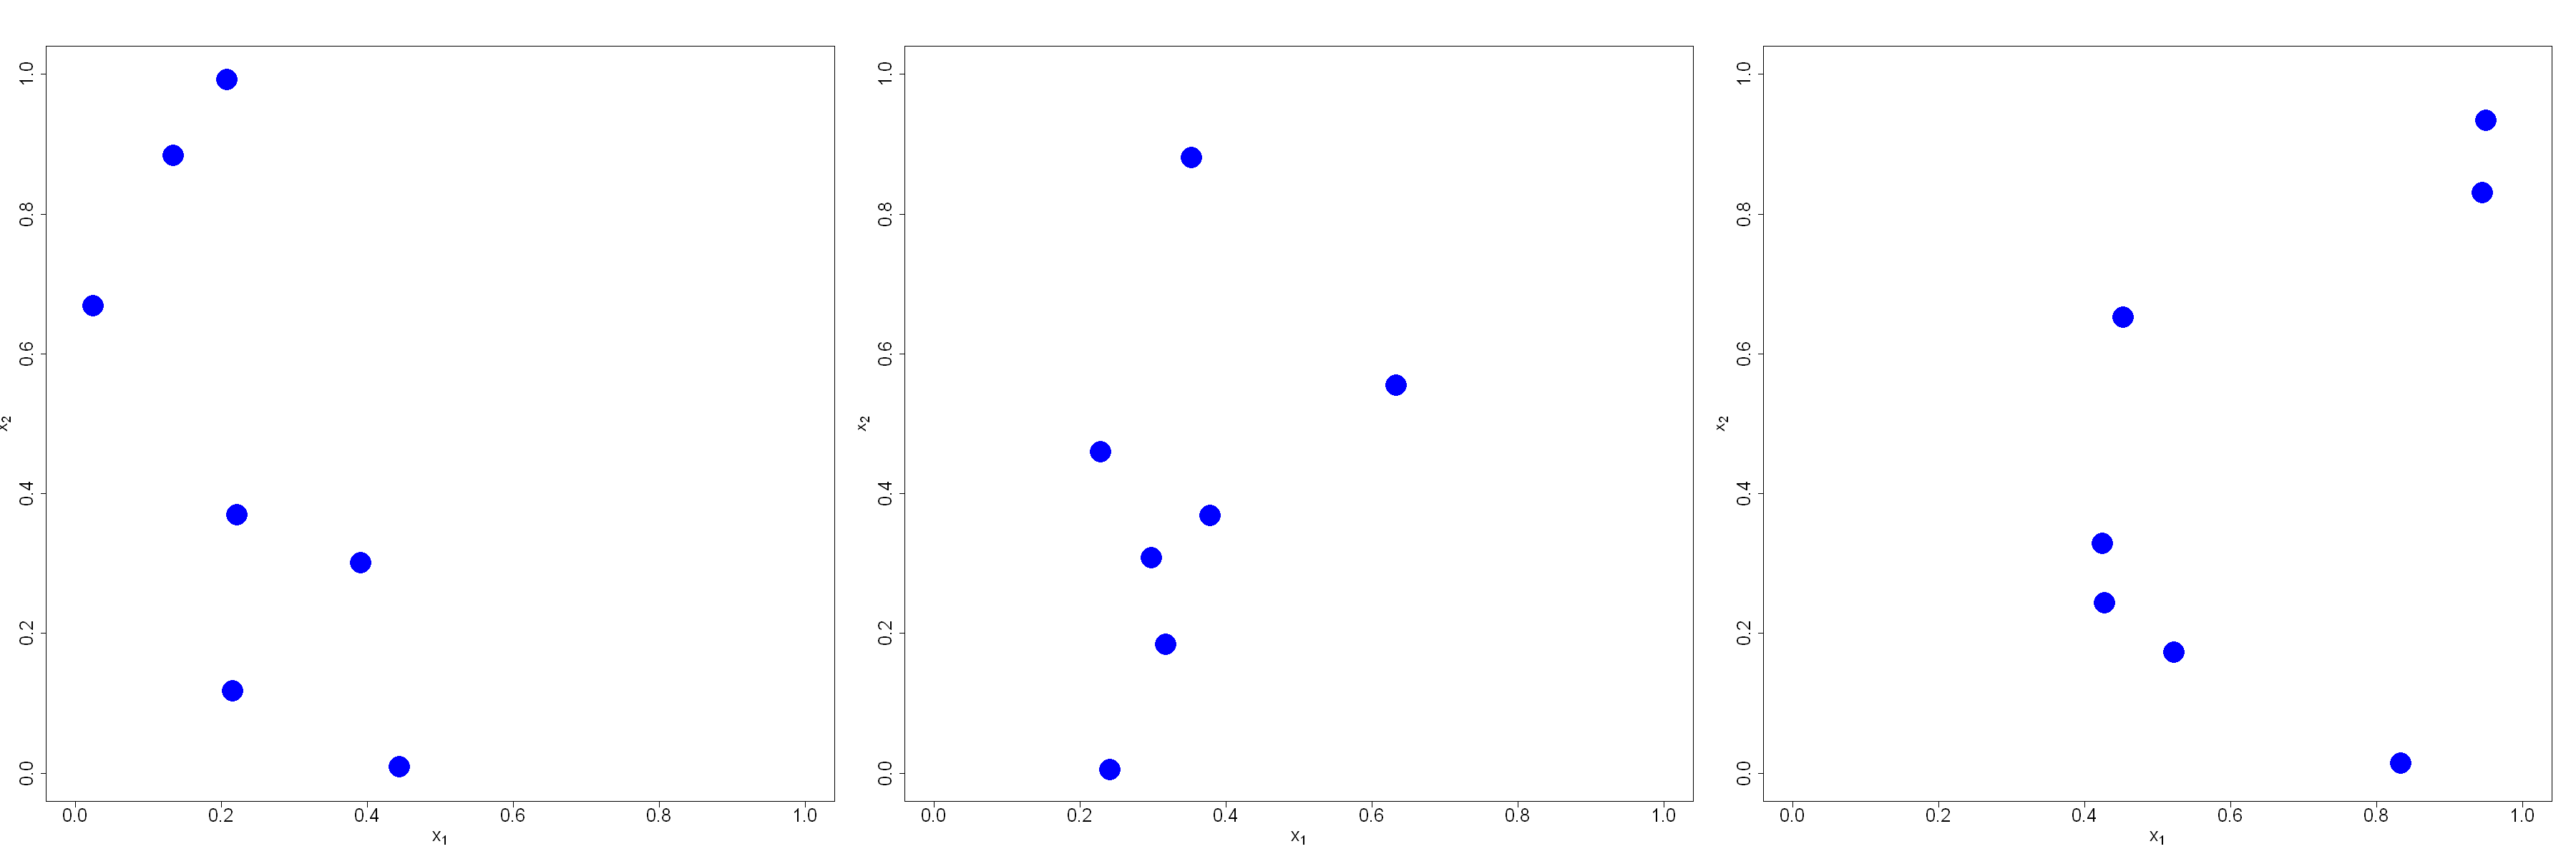

In [ ]:
options(repr.plot.width=30,repr.plot.height=10)
par(mfrow=c(1,3))
for(i in c(9,45,31)){
set.seed(i)
D=matrix(runif(7*2),nrow=7,ncol=2)
plot(D,xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),pch=16,col="blue",cex=5,cex.lab=2,cex.axis=2)
}

构建响应曲面的高斯过程模型：$h(\boldsymbol{x}) \sim GP(\mu, \tau^2R(\cdot))$。暂且假定均值 $\mu$、方差 $\tau^2$ 以及相关参数 $\theta$ 均为已知。现有观测数据集 $\{(\boldsymbol{x}_i, y_i)\}_{i=1}^n$，则 $h(\boldsymbol{x})$ 的后验分布满足：

$$
h(\boldsymbol{x})|y \sim \mathcal{N}(\hat{y}(\boldsymbol{x}), s^2(\boldsymbol{x}))
$$

其中：

$$
\hat{y}(\boldsymbol{x}) = \mu + \boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}(\boldsymbol{y} - \mu\boldsymbol{1})
$$

$$
s^2(\boldsymbol{x}) = \tau^2\left[1 - \boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})\right]
$$

式中 $\boldsymbol{r}(\boldsymbol{x}) = \{R(\boldsymbol{x}-\boldsymbol{x}_i)\}_{i=1}^n$，矩阵 $\boldsymbol{R} = \{R(\boldsymbol{x}_i-\boldsymbol{x}_j)\}_{i,j=1}^n$，定义形式见式 (2.13)。需要说明的是，$\boldsymbol{r}(\boldsymbol{x})$ 与矩阵 $\boldsymbol{R}$ 均依赖试验设计 $D = \{\boldsymbol{x}_i\}_{i=1}^n$ 和相关参数 $\theta$，为简化符号书写，表达式中并未显式标注该依赖关系。

我们的目标是确定试验设计方案，使得对任意属于试验区域 $\mathcal{X}$ 的自变量 $\boldsymbol{x}$，预测值 $\hat{y}(\boldsymbol{x})$ 尽可能贴近真实响应曲面 $h(\boldsymbol{x})$；经过标准化处理后，试验区域 $\mathcal{X}$ 通常为超立方体 $[0, 1]^p$。二者的接近程度可通过置信区间 $\hat{y}(\boldsymbol{x}) \pm z_{1-\alpha/2}s(\boldsymbol{x})$ 衡量，其中 $z_{1-\alpha/2}$ 为标准正态分布的上 $(1-\alpha/2)$ 分位数。因此优化目标可设定为最小化置信区间宽度 $2z_{1-\alpha/2}s(\boldsymbol{x})$。由于该宽度随自变量 $\boldsymbol{x}$ 变化，我们转而采用积分平均形式：

$$
\min_{D}\int_{\mathcal{X}} s(\boldsymbol{x})w(\boldsymbol{x})d\boldsymbol{x}
$$

式中 $w(\boldsymbol{x})$ 为权重函数，用于表征响应曲面在位置 $\boldsymbol{x}$ 处的重要程度。现阶段假定研究关注整个试验区域 $\mathcal{X}$，即区域内所有 $\boldsymbol{x}$ 的重要性均等。参数 $\tau$ 不会影响优化过程，故令 $\tau=1$。由此得到最优设计准则：最小化积分均方根误差：

$$
IRMSE(D; \theta)=\int_{\mathcal{X}}\sqrt{1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})}d\boldsymbol{x}
\tag{3.1}
$$

值得注意，该准则与参数 $\mu$、$\tau^2$ 无关，仅依赖相关参数 $\boldsymbol{\theta}$。式 (3.1) 物理意义更为直观（约瑟夫等人，2019），但在求解最优设计时，采用积分均方误差在数学计算上更为简便（萨克斯等人，1989）：

$$
\begin{align*}
IMSE(D; \theta)&=\int_{\mathcal{X}}\left\{1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})\right\}d\boldsymbol{x} \tag{3.2}\\
&=1-tr\left( \boldsymbol{R}^{-1}\int_{\mathcal{X}} \boldsymbol{r}(\boldsymbol{x})\boldsymbol{r}(\boldsymbol{x})'d\boldsymbol{x} \right)
\end{align*}
$$

上式中 $\mathcal{X} = [0, 1]^p$。当选取特定相关函数（例如高斯相关函数）时，该准则可完成解析积分求解（莱瑟曼等人，2018），从而简化优化运算。

我们选取一个一维问题，便于直观理解设计准则。积分均方误差（IMSE）准则必须先给定相关函数及其参数才能计算。取相关函数 $R(x) = \exp(-x^2/\theta^2)$，并令 $\theta=0.1$。图 3.2 左上子图展示了包含 10 个试验点的等距设计

$$
D_1=\left\{\frac{i-1}{n-1}\right\}_{i=1}^n
$$

以及包含 10 个试验点的切比雪夫设计

$$
D_2=\left\{0.5+0.5\cos\left(\frac{\pi(i-0.5)}{n}\right)\right\}_{i=1}^n
$$

（设定 $n=10$）对应的均方根误差 RMSE（等价于缩放后后验标准差 $s(x)/\tau$）。可以看到：在试验点位置处 RMSE 取值为 0，随着预测点远离试验点，RMSE 逐渐增大。切比雪夫设计在区间边界附近分配了更多试验点，因此边界区域的 RMSE 较小，但区间中心位置的 RMSE 会变大。我们可通过计算式 (3.2) 中的积分均方误差 IMSE 对比两种设计方案。借助数值积分计算可得：$\text{IMSE}(D_1;0.1)=0.0705$，$\text{IMSE}(D_2;0.1)=0.1227$，说明等距设计表现更优。我们可以对 IMSE 准则做优化求解最优试验设计。但 IMSE 的优化求解难度很高：目标函数包含相关矩阵的逆矩阵 $\boldsymbol{R}^{-1}$、求解过程需要数值积分，并且目标函数属于多峰函数。本文在 R 语言的 optim 函数中采用无导数有限内存 BFGS（L-BFGS）优化算法，以等距设计作为优化初始值求解最优设计。最优设计 $D_3$ 绘制在同一张图的左下子图中，其积分均方误差 $\text{IMSE}(D_3;0.1)=0.0496$。不难发现，该最优设计将试验点向区间中心聚拢，致使区间边界处的 RMSE 变大，但整体的积分均方误差实现了进一步降低。

> **图 3.2** 四种试验设计对应的均方根误差。若依托对应设计采集的数据拟合高斯过程模型，且模型相关函数取 $R(\Delta) = \exp(-\Delta^2/\theta^2)$、$\theta=0.1$，则纵坐标正比于置信区间宽度。

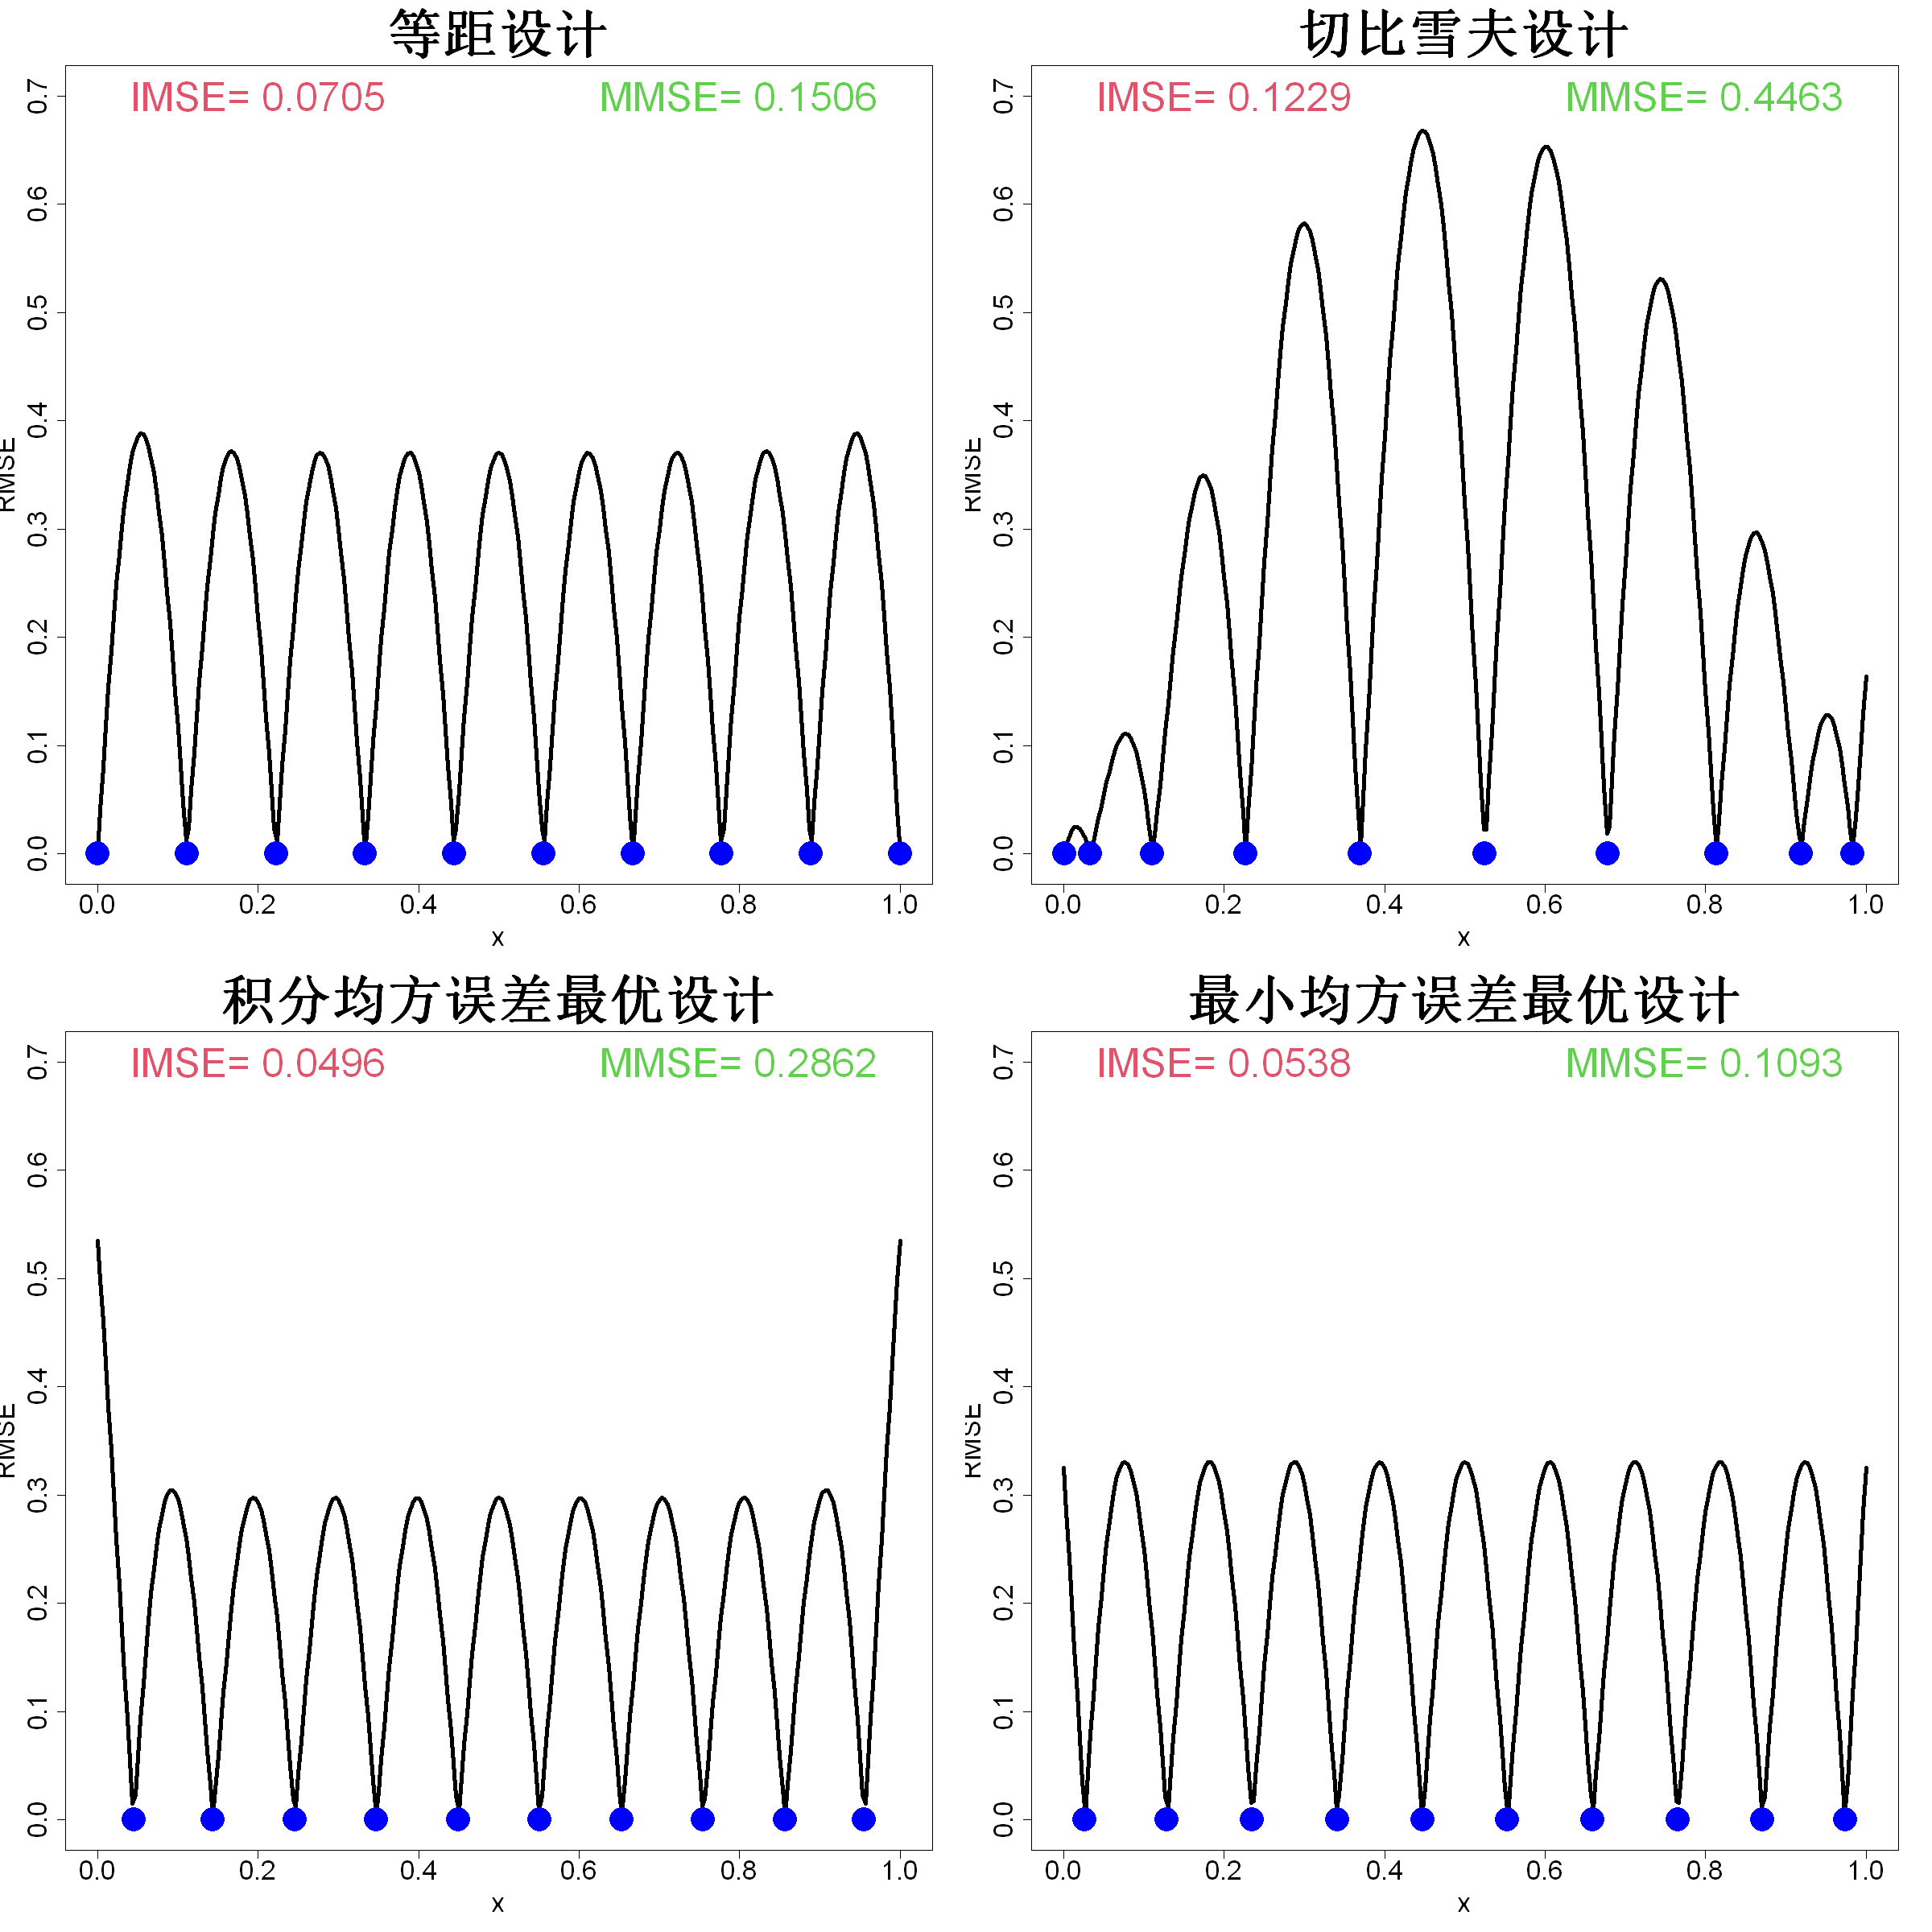

In [ ]:
options(repr.plot.width=20,repr.plot.height=20)
par(mfrow=c(2,2))
theta=.1
n=10
test=seq(0,1,length=301)
D=((1:n)-1)/(n-1)
library(gpcrit)
sa=gp_rmse(D,theta,test)
plot(test,sa,type="l",xlab="x",ylab="RMSE",cex.lab=2,ylim=c(0,.7),cex.axis=2,main="等距设计",cex.main=4,lwd=4)
points(cbind(D,0),pch=16,col="blue",cex=4)
text(.2,.7,paste("IMSE=",round(imse(D,theta),4)),cex=3,col=2)
text(.8,.7,paste("MMSE=",round(mmse(D,theta),4)),cex=3,col=3)

D=.5+.5*cos((pi*(1:n)-.5)/n)
sa=gp_rmse(D,theta,test)
plot(test,sa,type="l",xlab="x",ylab="RMSE",cex.lab=2,ylim=c(0,.7),cex.axis=2,main="切比雪夫设计",cex.main=4,lwd=4)
points(cbind(D,0),pch=16,col="blue",cex=4)
text(.2,.7,paste("IMSE=",round(imse(D,theta),4)),cex=3,col=2)
text(.8,.7,paste("MMSE=",round(mmse(D,theta),4)),cex=3,col=3)

D0=((1:n)-.5)/n
D=optim(D0,function(D)imse(D,theta),lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")$par
sa=gp_rmse(D,theta,test)
plot(test,sa,type="l",xlab="x",ylab="RMSE",cex.lab=2,ylim=c(0,.7),cex.axis=2,main="积分均方误差最优设计",cex.main=4,lwd=4)
points(cbind(D,0),pch=16,col="blue",cex=4)
text(.2,.7,paste("IMSE=",round(imse(D,theta),4)),cex=3,col=2)
text(.8,.7,paste("MMSE=",round(mmse(D,theta),4)),cex=3,col=3)

D=optim(D0,function(D)mmse(D,theta),lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")$par
sa=gp_rmse(D,theta,test)
plot(test,sa,type="l",xlab="x",ylab="RMSE",cex.lab=2,ylim=c(0,.7),cex.axis=2,main="最小均方误差最优设计",cex.main=4,lwd=4)
points(cbind(D,0),pch=16,col="blue",cex=4)
text(.2,.7,paste("IMSE=",round(imse(D,theta),4)),cex=3,col=2)
text(.8,.7,paste("MMSE=",round(mmse(D,theta),4)),cex=3,col=3)
par(mfrow=c(1,1))

注意到

$$
\int_X \left\{1 - \boldsymbol{r}(\boldsymbol{x})'R^{-1}\boldsymbol{r}(\boldsymbol{x})\right\} dx \le \max_{x\in X} \left\{1 - \boldsymbol{r}(\boldsymbol{x})'R^{-1}\boldsymbol{r}(\boldsymbol{x})\right\}
$$

我们可以定义另一准则，即最小化最大均方误差（萨克斯等人，1989）：

$$
MMSE(D; \theta) = \max_{x\in X} \left\{1 - \boldsymbol{r}(\boldsymbol{x})'R^{-1}\boldsymbol{r}(\boldsymbol{x})\right\}
\tag{3.3}
$$

积分均方误差（IMSE）设计与最大均方误差（MMSE）设计可看作线性回归模型下 I 最优设计 (2.37)、G 最优设计 (2.36) 在高斯过程中的对应形式。

通过最小化均方误差得到的最优设计方案（$D_4$）展示于图 3.2 的右下子图中。可以发现，该设计能够将最大不确定度降至最低；相较于集成均方误差设计方案，该最优设计只是略微将采样点向边界靠拢即可实现上述效果。四种设计方案各自对应的均方误差数值同样标注在图 3.2 中。

上述所有计算均基于相关长度 $\theta=0.1$ 的高斯相关函数完成。在实际研究中，无法在开展实验前预先获知尺度参数的取值。因此，探究该参数是否会对最优试验设计产生影响具有重要意义。图 3.3 上方子图绘制了积分均方误差（IMSE）与最小最大均方误差（MMSE）的数值曲线。可以看出两类误差数值随 $\theta$ 变化显著。当 $\theta$ 取值极小或极大时，各类试验设计的表现趋于一致。该现象可以合理解释：$\theta$ 取值较小时，响应曲面起伏剧烈，全部 10 组试验设计均难以精准拟合该响应曲面；与之类似，$\theta$ 取值较大时，响应曲面平缓光滑，所有试验设计均可较好地完成曲面拟合。只有当 $\theta$ 处于中间区间时，不同试验设计的性能才会出现明显差异。参照萨克斯等人（1989）的研究方式，可定义相对效率用以区分不同试验设计的优劣，对应公式如下：

相对积分均方效率：

$$
RE_I(D_i; \boldsymbol{\theta})=
\frac{\min_i \text{IMSE}(D_i; \boldsymbol{\theta})}
{\text{IMSE}(D_i; \boldsymbol{\theta})}
$$

相对最小最大均方效率：

$$
RE_M(D_i; \boldsymbol{\theta})=
\frac{\min_i \text{MMSE}(D_i; \boldsymbol{\theta})}
{\text{MMSE}(D_i; \boldsymbol{\theta})}
$$

其中 $i=1,2,3,4$。

> **图 3.3** 图 3.2 中四种设计方案在积分均方误差（IMSE）与最小最大均方误差（MMSE）指标下的相对效率。将参数 $\theta$ 固定为 0.1，即可求得分别适配积分均方误差、最小最大均方误差的最优设计方案。

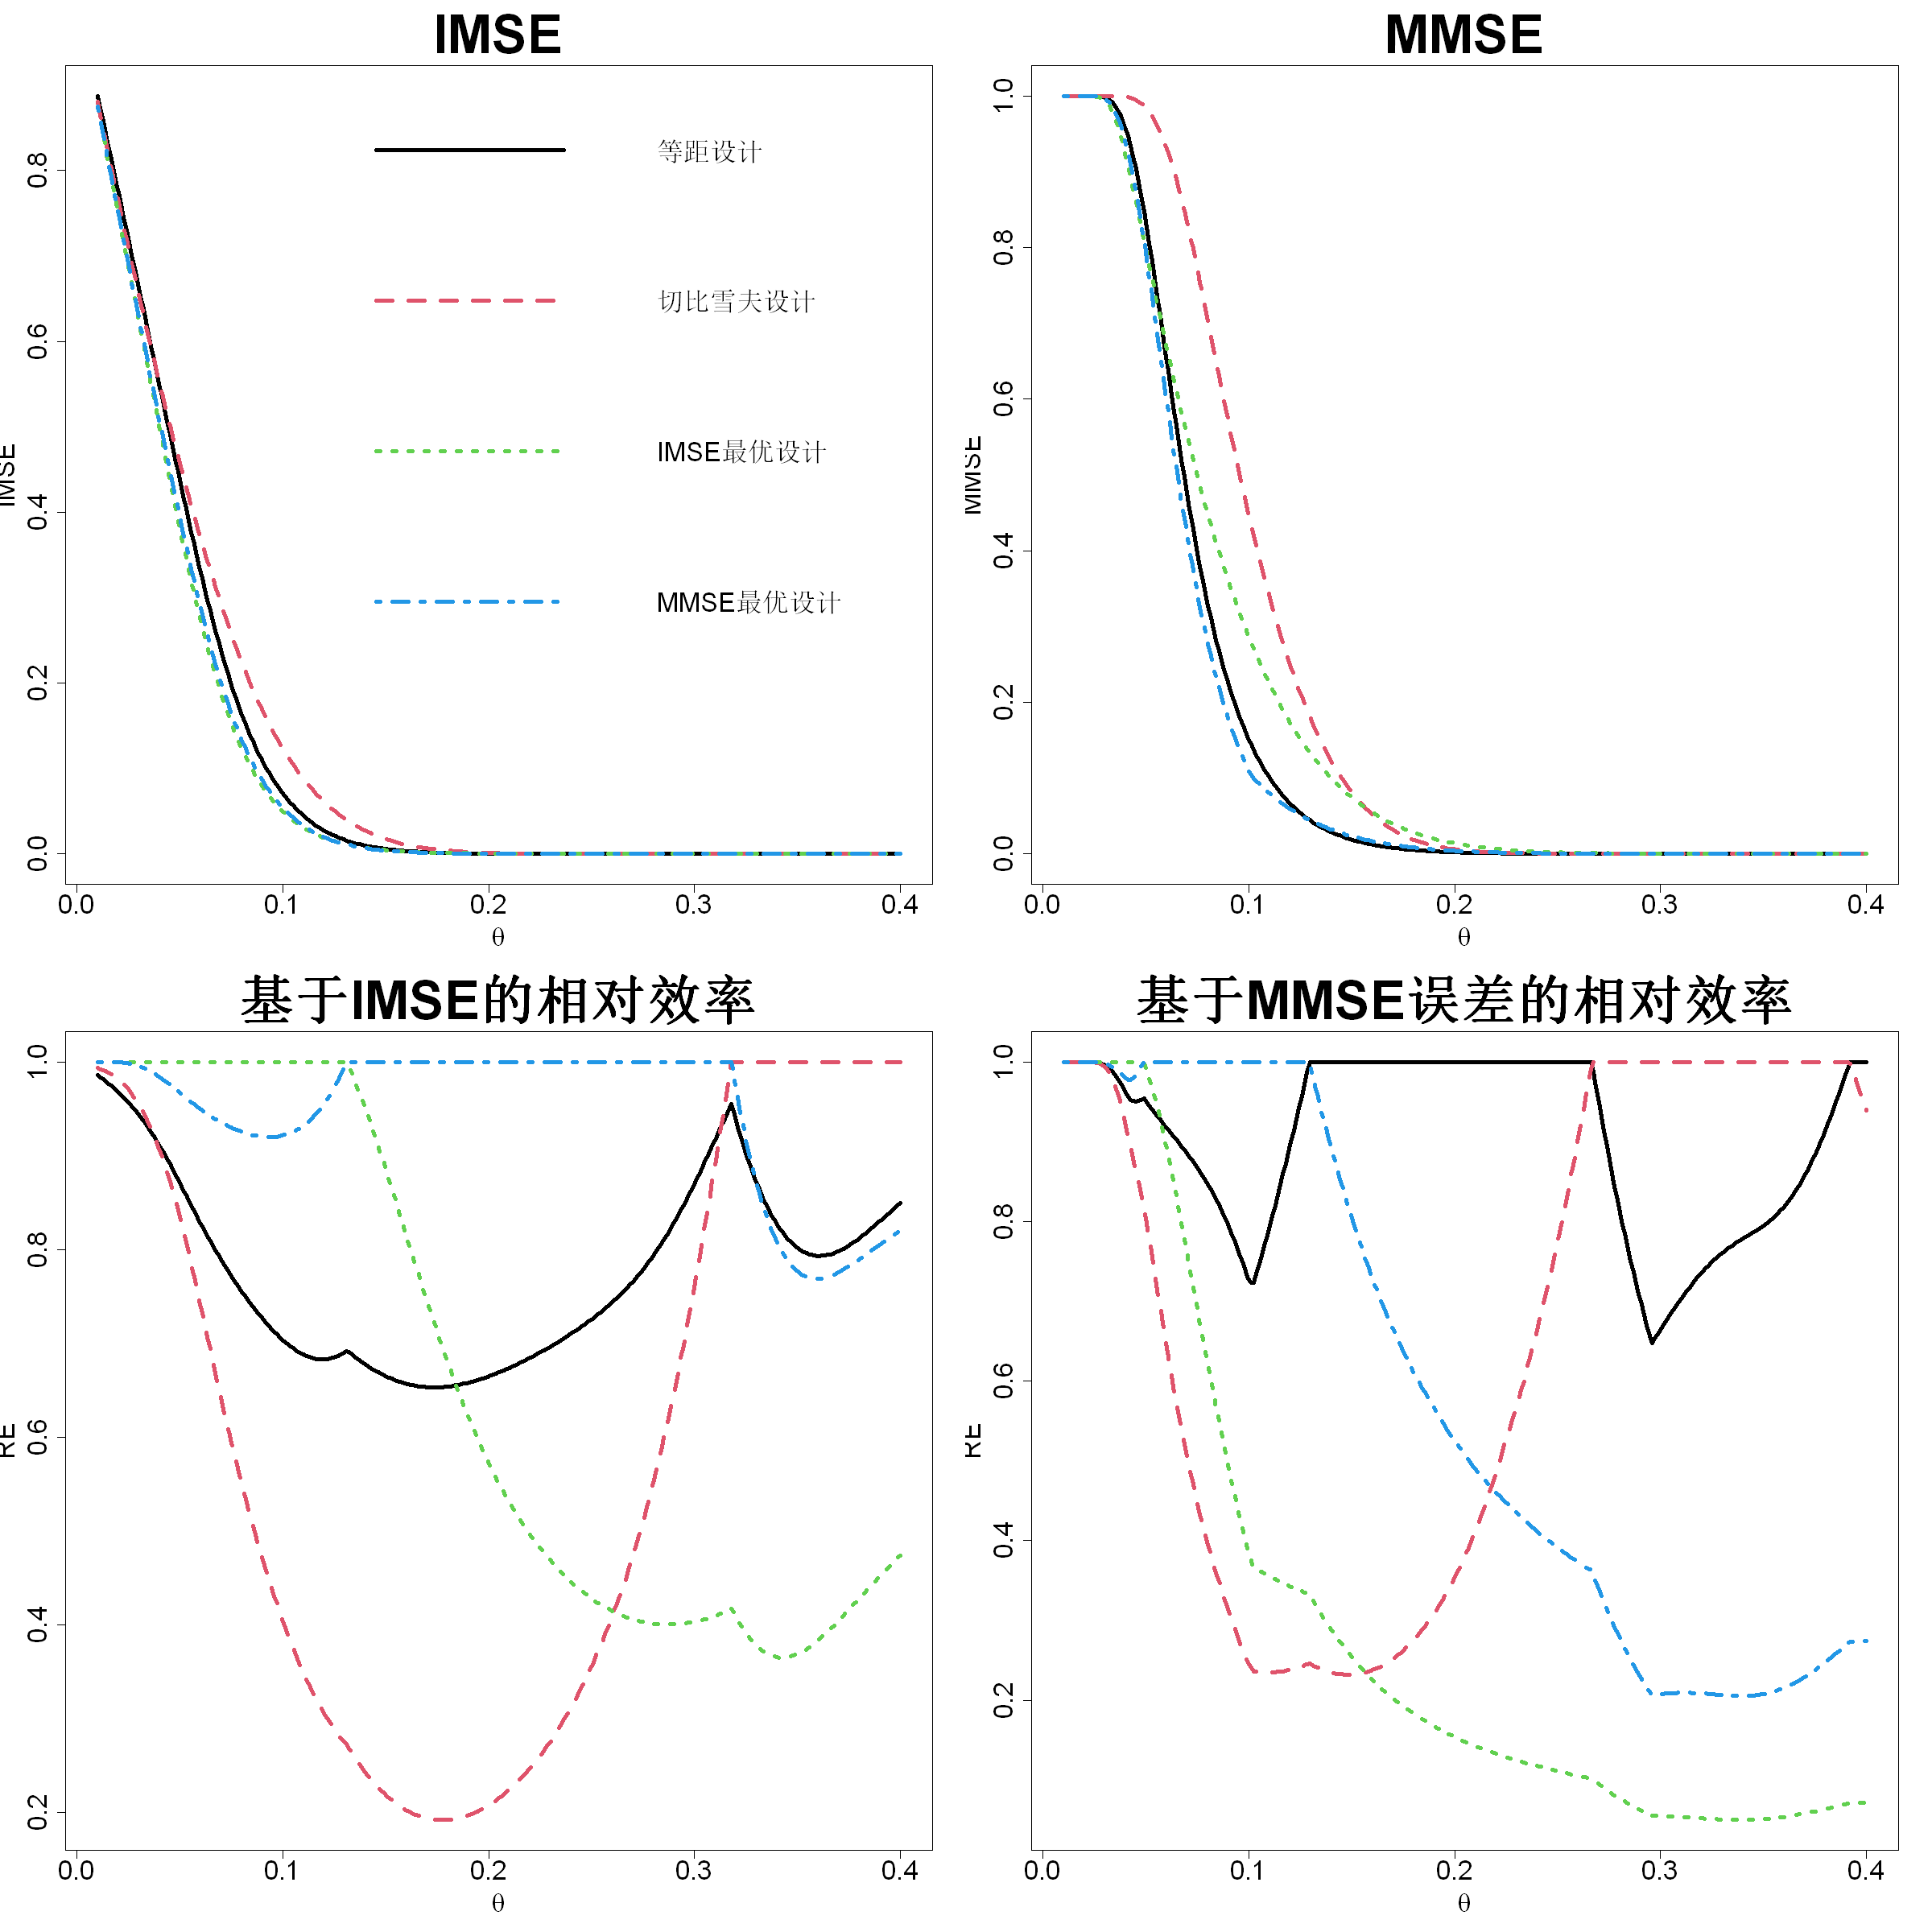

In [3]:
options(repr.plot.width=20,repr.plot.height=20)
par(mfrow=c(2,2))
r=function(x,D)exp(-(outer(x,D,"-")/theta)^2)
s=function(x){
Z=solve(R+10^(-6)*diag(n),t(r(x,D)))
sqrt(1-colSums(t(r(x,D))*Z))
}
imse_local=function(D){
R=r(D,D)
s=function(x){
Z=solve(R+10^(-6)*diag(n),t(r(x,D)))
1-colSums(t(r(x,D))*Z)
}
integrate(s,0,1)$val
}
mmse_local=function(D){
R=r(D,D)
s=function(x){
Z=solve(R+10^(-6)*diag(n),t(r(x,D)))
1-colSums(t(r(x,D))*Z)
}
test=seq(0,1,length=301)
max(s(test))
}
n=10
theta=.1
D1=((1:n)-1)/(n-1)
D2=.5+.5*cos((pi*(1:n)-.5)/n)
D0=((1:n)-.5)/n
D3=optim(D0,imse_local,lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")$par
D4=optim(D0,mmse_local,lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")$par

ev=seq(.01,.4,length=301)
IR=MR=matrix(0,nrow=301,ncol=4)
for(i in 1:301){
theta=ev[i]
IR[i,]=c(imse_local(D1),imse_local(D2),imse_local(D3),imse_local(D4))
MR[i,]=c(mmse_local(D1),mmse_local(D2),mmse_local(D3),mmse_local(D4))
}

matplot(ev,IR,type="l",xlab=expression(theta),ylab="IMSE",lwd=4,main="IMSE",cex.main=4,cex.lab=2,cex.axis=2)
legend(.1,1,legend=c("等距设计","切比雪夫设计","IMSE最优设计","MMSE最优设计"),lty=1:4,col=1:4,lwd=4,bty="n",cex=2)
matplot(ev,MR,type="l",xlab=expression(theta),ylab="MMSE",lwd=4,main="MMSE",cex.main=4,cex.lab=2,cex.axis=2)

IRR=apply(IR,1,min)/IR
matplot(ev,IRR,type="l",xlab=expression(theta),ylab="RE",lwd=4,main="基于IMSE的相对效率",cex.main=4,cex.lab=2,cex.axis=2)
MRR=apply(MR,1,min)/MR
matplot(ev,MRR,type="l",xlab=expression(theta),ylab="RE",lwd=4,main="基于MMSE误差的相对效率",cex.main=4,cex.lab=2,cex.axis=2)
par(mfrow=c(1,1))

四种设计方案在积分均方误差（IMSE）与最小均方误差（MMSE）指标下的相对效率绘制于图 3.3 下方子图中。可以看出，最优设计方案会随着参数 $\theta$ 取值的变化而改变。例如，当 $\theta < 0.3$ 时，切比雪夫设计在积分均方误差指标下表现很差，但当 $\theta > 0.3$ 时该设计性能最优。这一结果对我们的最优设计方案而言是不利的。不过仍存在可行思路：等间隔设计与最小均方误差最优设计即便无法在任意 $\theta$ 取值下达到最优，但其在全部 $\theta$ 取值范围内的表现都较为稳定。因此，我们需要求解对参数 $\theta$ 具备鲁棒性的设计方案，该优化问题可表示为：

$$
\max_{D}\min_{\boldsymbol{\theta}\in\Theta}\frac{\text{IMSE}(D^*(\boldsymbol{\theta}); \boldsymbol{\theta})}{\text{IMSE}(D; \boldsymbol{\theta})}
$$

其中

$$
D^*(\boldsymbol{\theta}) = \argmin_{\boldsymbol{\theta}\in\Theta}\text{IMSE}(D; \boldsymbol{\theta})
$$

且 $\Theta \subset[0, +\infty)^p$。鲁棒最小均方误差最优设计可按照相同方式定义。即便对 $p$ 维参数空间 $\Theta$ 进行离散化处理，仍需要针对大量 $\theta$ 取值求解积分均方误差最优设计或最小均方误差最优设计，因此该问题求解难度极大。

由图 3.3 可见，当 $\theta$ 趋近于 0（即相关性趋近于 0）时，所有设计方案的表现均较差，该情形对应变量近似相互独立。在此条件下，矩阵 $\boldsymbol{R}$ 趋近于单位矩阵 $\boldsymbol{I}$，因此无需对矩阵 $\boldsymbol{R}$ 求逆即可计算集成均方误差（IMSE）准则与最小均方误差（MMSE）准则，能够大幅降低计算量。此外，在该极限条件下求得的各类设计方案，在相关性较强的场景中同样具备不错的效果。这类设计被称作填充设计，不仅构造难度更低，还能够抵御相关结构设定错误带来的影响，具备稳健性。因此我们将填充设计作为计算机试验的初始设计。不过在深入讲解填充设计之前，还需要了解基于模型的试验设计中另一重要概念。